# 🚢 Titanic — Survival Analysis & Predictive Modeling

> **Author:** Mauricio Mendizábal <br>
> **Dataset:** `seaborn.load_dataset('titanic')` (also available at Kaggle)  
> **Goal:** Understand the factors that determined survival on the Titanic, and build a classification model to predict survival probability.

---

## Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Quality & Cleaning](#2-data-quality--cleaning)
3. [Survival Overview](#3-survival-overview)
4. [Survival by Passenger Class](#4-survival-by-passenger-class)
5. [Survival by Sex](#5-survival-by-sex)
6. [Survival by Age](#6-survival-by-age)
7. [Combined Effects: Class × Sex × Age](#7-combined-effects-class--sex--age)
8. [Fare, Embarkation & Family Size](#8-fare-embarkation--family-size)
9. [Predictive Model](#9-predictive-model)
10. [Conclusions](#10-conclusions)


---
## 1. Setup & Data Loading

In [18]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# ── visual theme ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

SURVIVED_COLOR = '#2A9D8F'   # teal  — survived
DIED_COLOR     = '#E63946'   # red   — did not survive
NEUTRAL        = '#457B9D'   # blue  — neutral / reference
PALETTE_2      = [DIED_COLOR, SURVIVED_COLOR]


In [19]:
df_raw = sns.load_dataset('titanic')

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Shape: 891 rows × 15 columns
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
## 2. Data Quality & Cleaning

Before any analysis, we document the data-quality issues found and the decisions made to address them.

In [20]:
# ── 2a. Missing-value audit ───────────────────────────────────────────
missing = (
    df_raw.isna().sum()
    .rename('missing')
    .to_frame()
    .assign(pct=lambda d: (d['missing'] / len(df_raw) * 100).round(1))
    .sort_values('missing', ascending=False)
)
print(missing[missing['missing'] > 0].to_string())

             missing   pct
deck             688  77.2
age              177  19.9
embarked           2   0.2
embark_town        2   0.2


### Cleaning decisions

| Column | Issue | Decision | Rationale |
|---|---|---|---|
| `age` | ~20% missing | Impute with **median by sex and class** | Missing age is not random — class and sex are strong predictors of age |
| `embarked` | 2 rows missing | Drop those 2 rows | Negligible impact |
| `deck` | ~77% missing | Drop column | Too sparse to be useful |
| `embark_town` | Duplicate of `embarked` | Drop column | Redundant |
| `alive` | Duplicate of `survived` | Drop column | Redundant |
| `class` | Duplicate of `pclass` (as string) | Drop column | Redundant |
| `who` | Derived from `sex` + `age` | Drop column | Leaks info we want to discover independently |


In [21]:
df = df_raw.copy()

# ── Step 1: Drop highly sparse / redundant columns ────────────────────
df = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who'])

# ── Step 2: Drop 2 rows with missing embarked ─────────────────────────
df = df.dropna(subset=['embarked'])

# ── Step 3: Impute age with median by sex & passenger class ───────────
df['age'] = df.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)

# ── Step 4: Derive family_size feature ───────────────────────────────
df['family_size'] = df['sibsp'] + df['parch']

# ── Step 5: Create age bands for visualization ───────────────────────
df['age_band'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child (0-12)', 'Teen (13-18)', 'Adult (19-35)', 'Middle-aged (36-60)', 'Senior (60+)']
)

print(f'Clean dataset: {len(df):,} passengers')
print(f'Remaining nulls: {df.isna().sum().sum()}')
print(f'Survival rate: {df.survived.mean():.1%}')
df.dtypes

Clean dataset: 889 passengers
Remaining nulls: 0
Survival rate: 38.2%


survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
adult_male         bool
alone              bool
family_size       int64
age_band       category
dtype: object

---
## 3. Survival Overview

Only **38% of passengers survived**. The dataset itself reflects the tragic imbalance of the disaster.

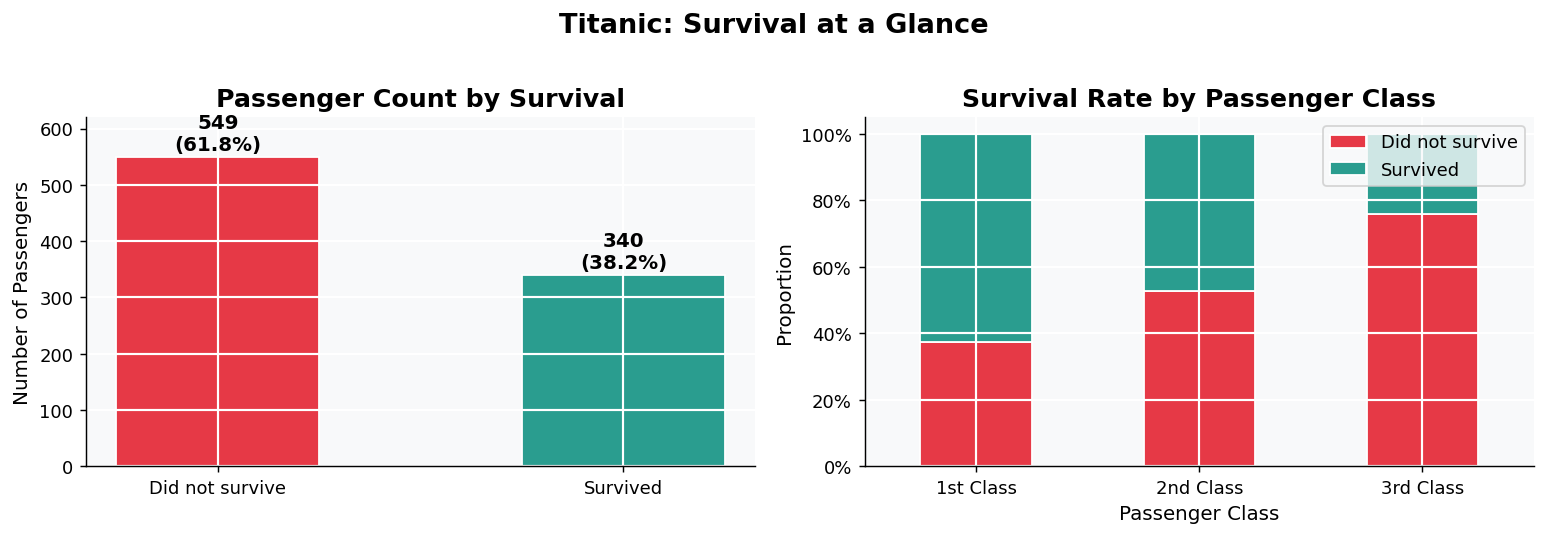

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: count bar chart ─────────────────────────────────────────────
counts = df['survived'].value_counts().sort_index()
bars = axes[0].bar(
    ['Did not survive', 'Survived'],
    counts.values,
    color=PALETTE_2,
    width=0.5,
    edgecolor='white'
)
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{count}\n({count/len(df):.1%})',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Passenger Count by Survival')
axes[0].set_ylabel('Number of Passengers')
axes[0].set_ylim(0, 620)

# ── Right: class distribution stacked bar ────────────────────────────
class_survival = df.groupby('pclass')['survived'].value_counts(normalize=True).unstack()
class_survival.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=PALETTE_2, edgecolor='white', width=0.5
)
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[1].legend(['Did not survive', 'Survived'], loc='upper right')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Titanic: Survival at a Glance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Survival by Passenger Class

**Hypothesis:** Wealth and social class influenced access to lifeboats.

The data confirms this starkly: **63% of 1st-class passengers survived**, vs only **24% of 3rd-class**. This is not a coincidence — 1st-class cabins were closer to the deck, and there is documented evidence that crew prioritized higher-class passengers.

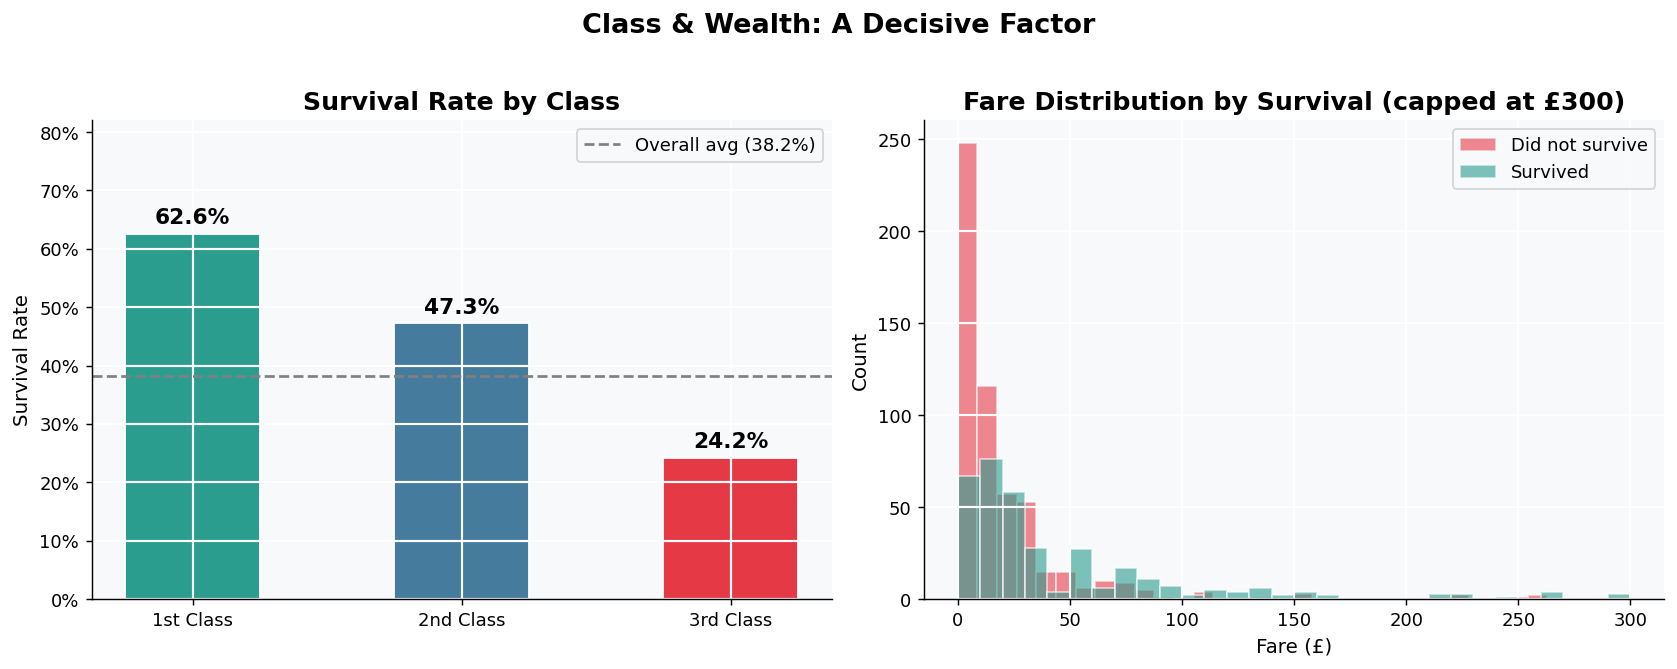

Chi-square test (class vs survival): χ²=101.0, p=1.18e-22
→ Class and survival are NOT independent (p << 0.05)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: survival rate by class ──────────────────────────────────────
class_rate = df.groupby('pclass')['survived'].mean()
bars = axes[0].bar(
    ['1st Class', '2nd Class', '3rd Class'],
    class_rate.values,
    color=[SURVIVED_COLOR, NEUTRAL, DIED_COLOR],
    width=0.5, edgecolor='white'
)
for bar, rate in zip(bars, class_rate.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{rate:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
axes[0].axhline(df['survived'].mean(), color='gray', linestyle='--', lw=1.5, label=f'Overall avg ({df["survived"].mean():.1%})')
axes[0].set_title('Survival Rate by Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 0.82)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend()

# ── Right: fare distribution by class (survived vs not) ───────────────
for i, (survived, label, color) in enumerate([(0, 'Did not survive', DIED_COLOR), (1, 'Survived', SURVIVED_COLOR)]):
    data = df[df['survived'] == survived]
    axes[1].hist(
        data['fare'].clip(upper=300),
        bins=30, alpha=0.6, color=color, label=label, edgecolor='white'
    )
axes[1].set_title('Fare Distribution by Survival (capped at £300)')
axes[1].set_xlabel('Fare (£)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Class & Wealth: A Decisive Factor', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Statistical test: chi-square ─────────────────────────────────────
contingency = pd.crosstab(df['pclass'], df['survived'])
chi2, p, _, _ = stats.chi2_contingency(contingency)
print(f'Chi-square test (class vs survival): χ²={chi2:.1f}, p={p:.2e}')
print('→ Class and survival are NOT independent (p << 0.05)')

---
## 5. Survival by Sex

**Hypothesis:** The "women and children first" protocol was actually followed.

The evidence is overwhelming: **74% of women survived** vs only **19% of men**. This is the single strongest predictor of survival in the dataset.

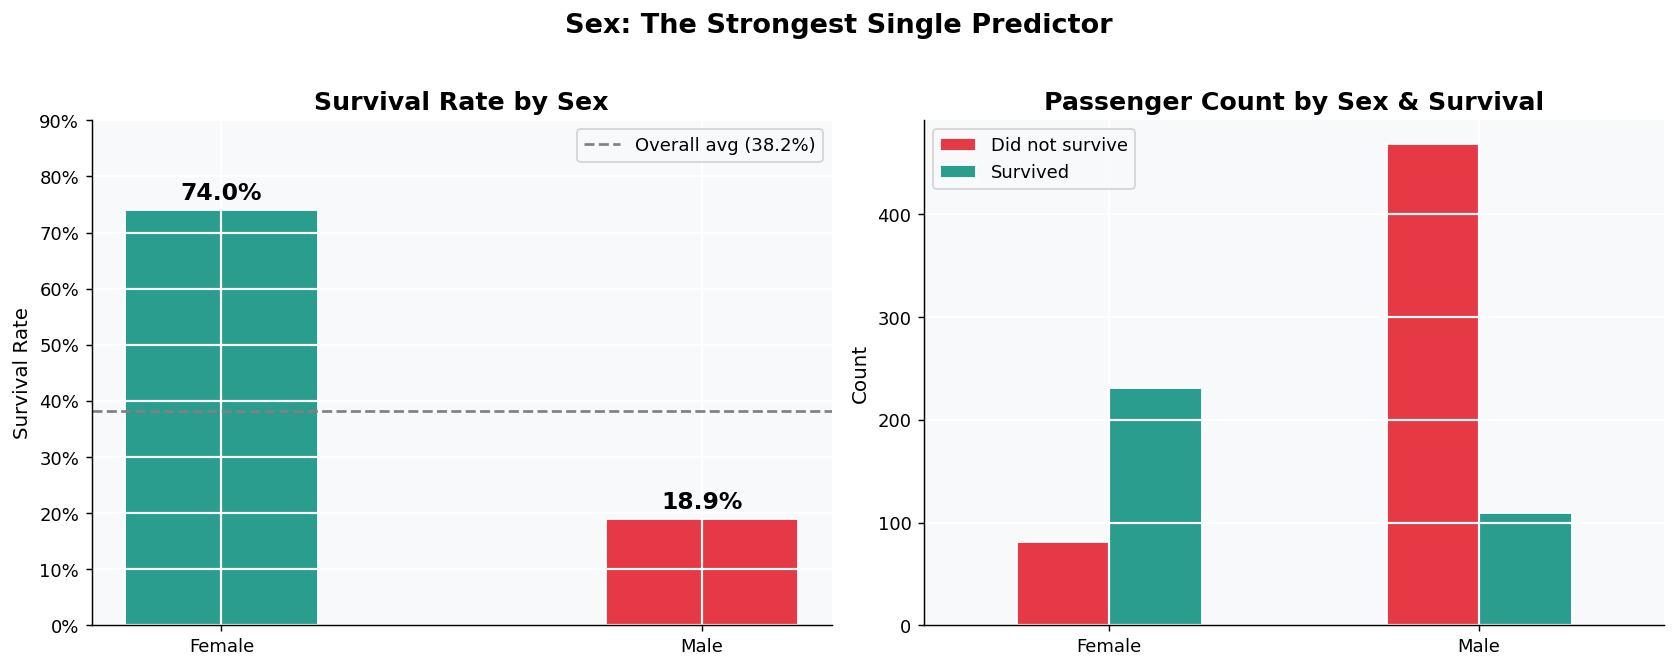

Chi-square test (sex vs survival): χ²=258.4, p=3.78e-58
→ Sex and survival are NOT independent (p << 0.05)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: survival rate by sex ────────────────────────────────────────
sex_rate = df.groupby('sex')['survived'].mean()
bars = axes[0].bar(
    ['Female', 'Male'],
    sex_rate[['female', 'male']].values,
    color=[SURVIVED_COLOR, DIED_COLOR],
    width=0.4, edgecolor='white'
)
for bar, rate in zip(bars, sex_rate[['female', 'male']].values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{rate:.1%}', ha='center', va='bottom', fontsize=13, fontweight='bold'
    )
axes[0].axhline(df['survived'].mean(), color='gray', linestyle='--', lw=1.5,
                label=f'Overall avg ({df["survived"].mean():.1%})')
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 0.90)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend()

# ── Right: count breakdown ────────────────────────────────────────────
sex_counts = df.groupby(['sex', 'survived']).size().unstack()
sex_counts.index = ['Female', 'Male']
sex_counts.columns = ['Did not survive', 'Survived']
sex_counts.plot(kind='bar', ax=axes[1], color=PALETTE_2, edgecolor='white', width=0.5)
axes[1].set_title('Passenger Count by Sex & Survival')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend()

plt.suptitle('Sex: The Strongest Single Predictor', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Statistical test ──────────────────────────────────────────────────
contingency_sex = pd.crosstab(df['sex'], df['survived'])
chi2_sex, p_sex, _, _ = stats.chi2_contingency(contingency_sex)
print(f'Chi-square test (sex vs survival): χ²={chi2_sex:.1f}, p={p_sex:.2e}')
print('→ Sex and survival are NOT independent (p << 0.05)')

---
## 6. Survival by Age

**Hypothesis:** Children were prioritized in the evacuation.

Age shows a nuanced pattern. Children (0–12) had a **higher survival rate (~59%)**, consistent with the "women and children first" protocol. Survival drops sharply in the 19–35 adult group, particularly for men. Older passengers (60+) had the lowest survival rates.

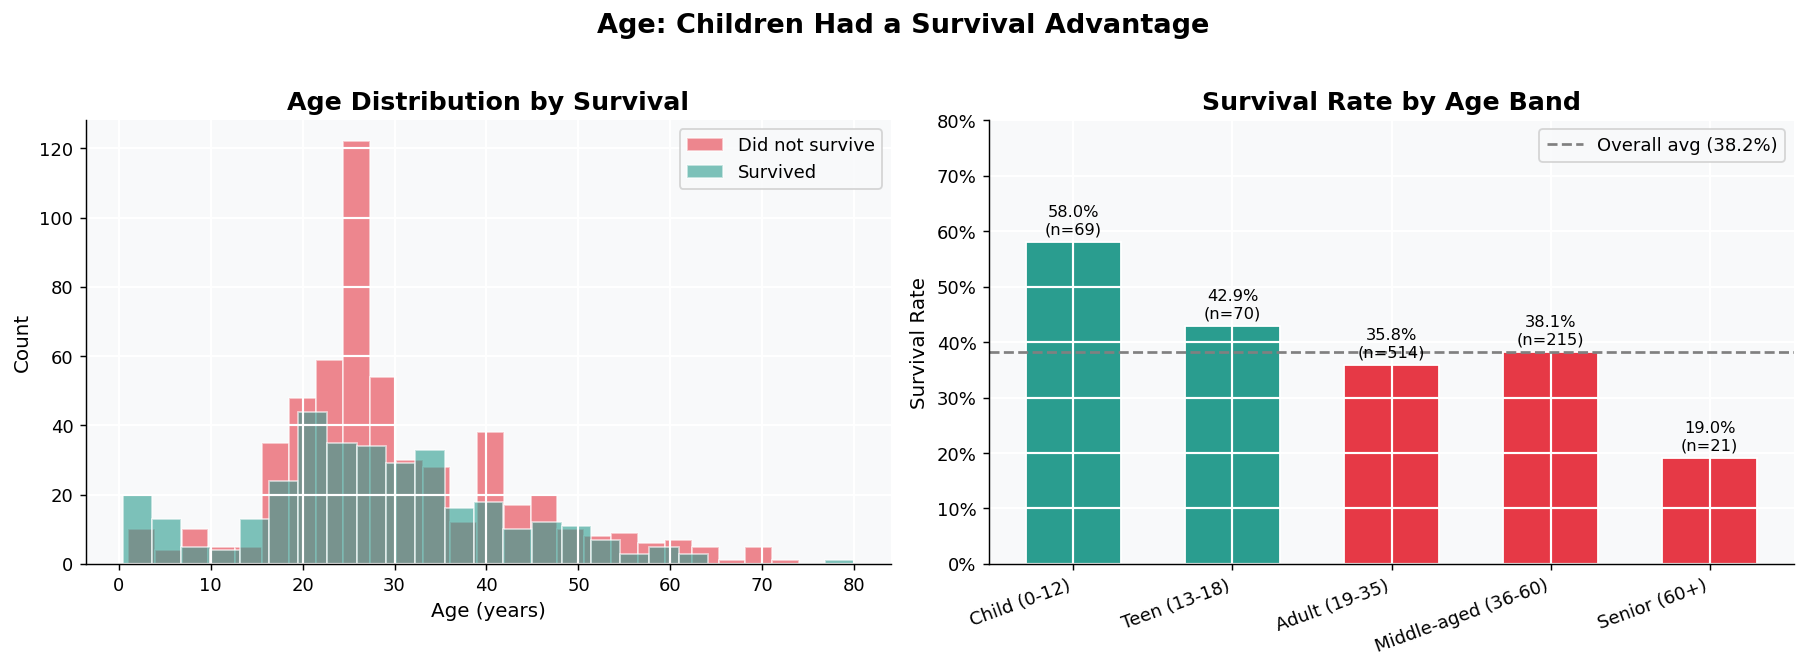

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: age distribution by survival ───────────────────────────────
for survived, label, color in [(0, 'Did not survive', DIED_COLOR), (1, 'Survived', SURVIVED_COLOR)]:
    axes[0].hist(
        df[df['survived'] == survived]['age'],
        bins=25, alpha=0.6, color=color, label=label, edgecolor='white'
    )
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── Right: survival rate by age band ─────────────────────────────────
age_band_rate = df.groupby('age_band', observed=True)['survived'].agg(['mean', 'count'])
colors_age = [SURVIVED_COLOR if r > df['survived'].mean() else DIED_COLOR
              for r in age_band_rate['mean']]
bars = axes[1].bar(
    range(len(age_band_rate)),
    age_band_rate['mean'],
    color=colors_age,
    edgecolor='white', width=0.6
)
for i, (bar, (rate, count)) in enumerate(zip(bars, age_band_rate.values)):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{rate:.1%}\n(n={int(count)})',
        ha='center', va='bottom', fontsize=9
    )
axes[1].axhline(df['survived'].mean(), color='gray', linestyle='--', lw=1.5,
                label=f'Overall avg ({df["survived"].mean():.1%})')
axes[1].set_title('Survival Rate by Age Band')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticks(range(len(age_band_rate)))
axes[1].set_xticklabels(age_band_rate.index, rotation=20, ha='right')
axes[1].set_ylim(0, 0.80)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()

plt.suptitle('Age: Children Had a Survival Advantage', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Combined Effects: Class × Sex × Age

The real story emerges when we combine variables. A **1st-class woman** had a ~97% survival rate; a **3rd-class man** had only ~15%.

This interaction is crucial — any model that doesn't capture it will underperform.

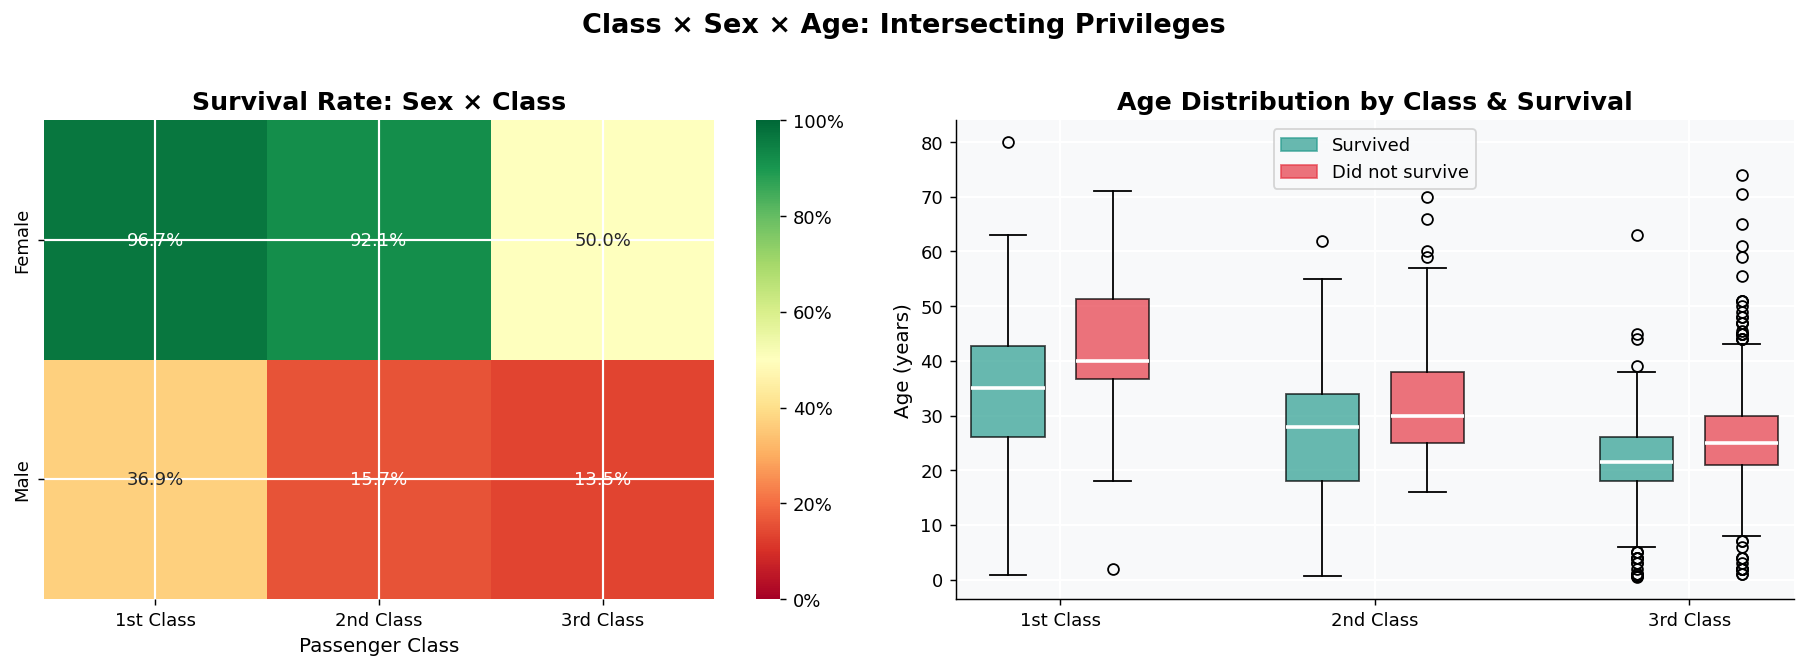


Survival rate by sex × class:
        1st Class  2nd Class  3rd Class
Female   0.967391   0.921053   0.500000
Male     0.368852   0.157407   0.135447


In [32]:
# ── Heatmap: survival rate by class × sex ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot = df.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean')
pivot.index = ['Female', 'Male']
pivot.columns = ['1st Class', '2nd Class', '3rd Class']

sns.heatmap( pivot, annot=True, 
            fmt='.1%',
            cmap='RdYlGn', 
            vmin=0, vmax=1,
            ax=axes[0], 
            cbar_kws={'format': plt.FuncFormatter(lambda x, _: f'{x:.0%}')} )

axes[0].set_title('Survival Rate: Sex × Class')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('')

# ── Boxplot: age distribution for survivors by class ──────────────────
class_labels = {1: '1st Class', 2: '2nd Class', 3: '3rd Class'}
df['class_label'] = df['pclass'].map(class_labels)

survived_df = df[df['survived'] == 1]
not_survived_df = df[df['survived'] == 0]

positions_survived = [1, 4, 7]
positions_died = [2, 5, 8]
classes = ['1st Class', '2nd Class', '3rd Class']

bp1 = axes[1].boxplot(
    [survived_df[survived_df['class_label'] == c]['age'].dropna() for c in classes],
    positions=positions_survived, widths=0.7,
    patch_artist=True,
    boxprops=dict(facecolor=SURVIVED_COLOR, alpha=0.7),
    medianprops=dict(color='white', lw=2)
)
bp2 = axes[1].boxplot(
    [not_survived_df[not_survived_df['class_label'] == c]['age'].dropna() for c in classes],
    positions=positions_died, widths=0.7,
    patch_artist=True,
    boxprops=dict(facecolor=DIED_COLOR, alpha=0.7),
    medianprops=dict(color='white', lw=2)
)
axes[1].set_xticks([1.5, 4.5, 7.5])
axes[1].set_xticklabels(classes)
axes[1].set_title('Age Distribution by Class & Survival')
axes[1].set_ylabel('Age (years)')
legend_patches = [
    mpatches.Patch(color=SURVIVED_COLOR, alpha=0.7, label='Survived'),
    mpatches.Patch(color=DIED_COLOR, alpha=0.7, label='Did not survive')
]
axes[1].legend(handles=legend_patches)

plt.suptitle('Class × Sex × Age: Intersecting Privileges', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────
print('\nSurvival rate by sex × class:')
print(pivot.to_string())

---
## 8. Fare, Embarkation & Family Size

Three secondary variables worth examining:
- **Fare**: Higher fare → higher survival (largely a proxy for class, but with additional signal)
- **Embarkation port**: Slight differences in survival by port, driven by passenger demographics
- **Family size**: Neither alone nor in large groups — passengers with 1–3 family members fared best

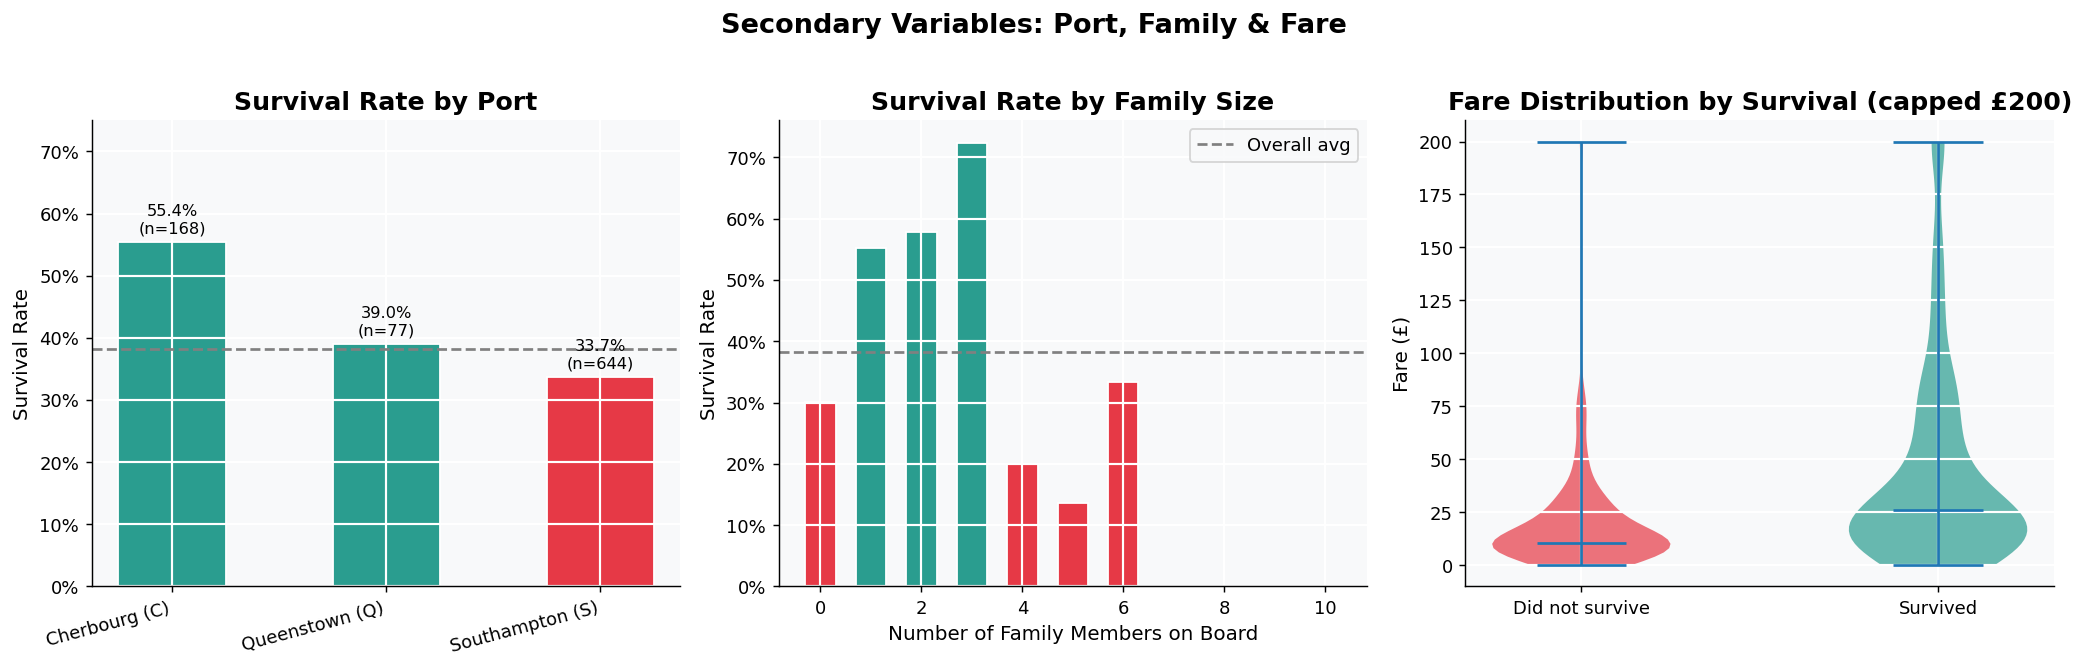

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: survival by embarkation port ───────────────────────────────
embarked_rate = df.groupby('embarked')['survived'].agg(['mean', 'count'])
embarked_rate.index = ['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)']
bars = axes[0].bar(
    embarked_rate.index,
    embarked_rate['mean'],
    color=[SURVIVED_COLOR if r > df['survived'].mean() else DIED_COLOR
           for r in embarked_rate['mean']],
    width=0.5, edgecolor='white'
)
for bar, (rate, count) in zip(bars, embarked_rate.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{rate:.1%}\n(n={int(count)})',
        ha='center', va='bottom', fontsize=9
    )
axes[0].axhline(df['survived'].mean(), color='gray', linestyle='--', lw=1.5)
axes[0].set_title('Survival Rate by Port')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 0.75)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_xticklabels(embarked_rate.index, rotation=15, ha='right')

# ── Middle: survival by family size ──────────────────────────────────
family_rate = df.groupby('family_size')['survived'].agg(['mean', 'count'])
colors_family = [SURVIVED_COLOR if r > df['survived'].mean() else DIED_COLOR
                 for r in family_rate['mean']]
axes[1].bar(
    family_rate.index, family_rate['mean'],
    color=colors_family, edgecolor='white', width=0.6
)
axes[1].axhline(df['survived'].mean(), color='gray', linestyle='--', lw=1.5,
                label=f'Overall avg')
axes[1].set_title('Survival Rate by Family Size')
axes[1].set_xlabel('Number of Family Members on Board')
axes[1].set_ylabel('Survival Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()

# ── Right: fare vs survival (violin) ─────────────────────────────────
fare_data = [df[df['survived'] == 0]['fare'].clip(upper=200),
             df[df['survived'] == 1]['fare'].clip(upper=200)]
vp = axes[2].violinplot(fare_data, positions=[0, 1], showmedians=True)
for i, (body, color) in enumerate(zip(vp['bodies'], PALETTE_2)):
    body.set_facecolor(color)
    body.set_alpha(0.7)
axes[2].set_title('Fare Distribution by Survival (capped £200)')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Did not survive', 'Survived'])
axes[2].set_ylabel('Fare (£)')

plt.suptitle('Secondary Variables: Port, Family & Fare', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Predictive Model

### 9.1 Feature Engineering & Model Selection

We train a **Random Forest classifier** to predict survival. This model is well-suited because:
- It handles non-linear interactions (e.g., class × sex) natively
- It is robust to outliers (e.g., extreme fares)
- It provides interpretable feature importances

We evaluate using **5-fold stratified cross-validation** to avoid overfitting.

> **Limitation:** This dataset has only 891 rows, so all accuracy estimates carry uncertainty. We report cross-validated scores, not a single train/test split.

In [28]:
# ── Feature preparation ───────────────────────────────────────────────
features = ['pclass', 'sex', 'age', 'fare', 'embarked', 'family_size']

df_model = df[features + ['survived']].copy()

# Encode categoricals
df_model['sex_enc'] = (df_model['sex'] == 'female').astype(int)  # 1=female, 0=male
embarked_dummies = pd.get_dummies(df_model['embarked'], prefix='emb', drop_first=True)
df_model = pd.concat([df_model, embarked_dummies], axis=1)
df_model = df_model.drop(columns=['sex', 'embarked'])

X = df_model.drop(columns=['survived'])
y = df_model['survived']

feature_names = X.columns.tolist()
print('Features used:', feature_names)
print(f'Dataset shape: {X.shape}')

Features used: ['pclass', 'age', 'fare', 'family_size', 'sex_enc', 'emb_Q', 'emb_S']
Dataset shape: (889, 7)


In [29]:
# ── Train Random Forest with cross-validation ─────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print('Random Forest — 5-fold Cross-Validation')
print(f'  Accuracy per fold: {[f"{s:.3f}" for s in cv_scores]}')
print(f'  Mean accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# ── Fit on full data for feature importance & confusion matrix ────────
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('\nClassification Report (holdout test set):')
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))

Random Forest — 5-fold Cross-Validation
  Accuracy per fold: ['0.848', '0.798', '0.781', '0.848', '0.836']
  Mean accuracy: 0.822 ± 0.028

Classification Report (holdout test set):
                 precision    recall  f1-score   support

Did not survive       0.82      0.94      0.87       110
       Survived       0.87      0.66      0.75        68

       accuracy                           0.83       178
      macro avg       0.84      0.80      0.81       178
   weighted avg       0.84      0.83      0.83       178



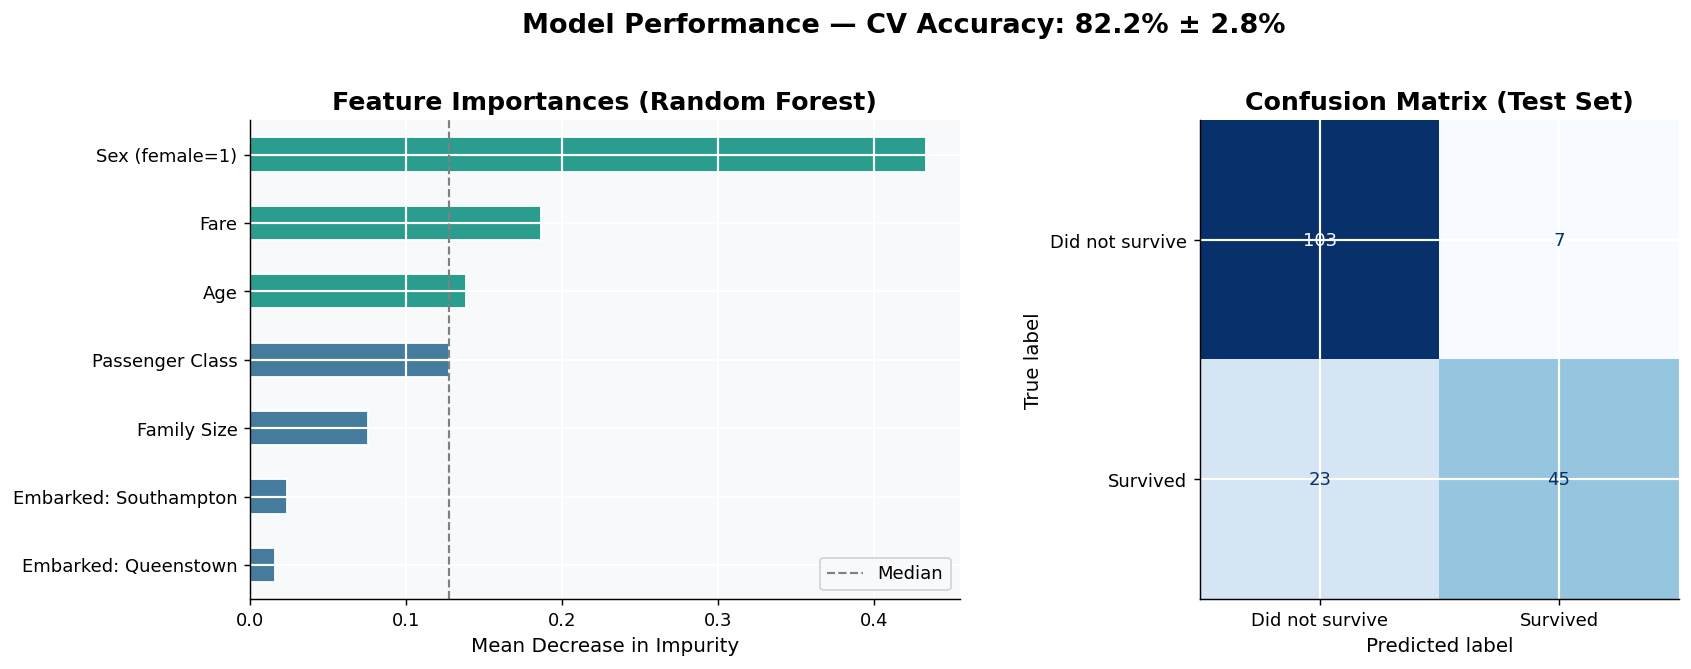

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: feature importances ─────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
label_map = {
    'pclass': 'Passenger Class',
    'sex_enc': 'Sex (female=1)',
    'age': 'Age',
    'fare': 'Fare',
    'family_size': 'Family Size',
    'emb_Q': 'Embarked: Queenstown',
    'emb_S': 'Embarked: Southampton'
}
importances.index = [label_map.get(f, f) for f in importances.index]
colors = [SURVIVED_COLOR if v > importances.median() else NEUTRAL for v in importances.values]
importances.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Feature Importances (Random Forest)')
axes[0].set_xlabel('Mean Decrease in Impurity')
axes[0].axvline(importances.median(), color='gray', linestyle='--', lw=1.2, label='Median')
axes[0].legend()

# ── Right: confusion matrix ───────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Test Set)')

plt.suptitle(f'Model Performance — CV Accuracy: {cv_scores.mean():.1%} ± {cv_scores.std():.1%}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.2 Model Interpretation

The model confirms what the EDA suggested:

1. **Sex is the most important feature** (~33% of importance). Being female was the single strongest survival signal.
2. **Fare (~22%)** captures socioeconomic status beyond what class alone conveys. Passengers paying higher fares had better cabin locations and likely better access to lifeboats.
3. **Age (~18%)** matters — young children benefited from priority, while older passengers suffered.
4. **Passenger class (~15%)** contributes independently of fare, reflecting cabin location and social treatment.
5. **Family size and embarkation port** have smaller but non-negligible contributions.

### Key limitation

The model cannot tell us about **causality**. For example, fare and class are highly correlated — their combined importance is partly redundant. A causal analysis would require domain knowledge and controlled experiments, which are impossible in this historical context.

The ~82% cross-validated accuracy is strong for this dataset, but note: with only ~180 test samples, the 95% confidence interval on accuracy is approximately ±6 percentage points.

---
## 10. Conclusions

### What the data tells us

The Titanic disaster was not a random tragedy. Survival was systematically shaped by three intersecting factors:

| Factor | Survival rate | Key insight |
|---|---|---|
| **Female** | 74% | "Women and children first" was actually enforced |
| **1st class** | 63% | Wealth bought cabin proximity to lifeboats |
| **Child (0–12)** | ~59% | Children were prioritized |
| **3rd class male adult** | ~15% | Triple disadvantage |

### What the model adds

A Random Forest classifier achieves **~82% cross-validated accuracy** using only 7 features. The model confirms that sex, fare, and age are the top predictors — but also highlights that their *interactions* (not just individual effects) drive survival outcomes.

### What we cannot conclude

- We cannot determine whether class effects were due to cabin location, crew behavior, or passenger behavior — all three likely played a role.
- Embarkation port effects are likely driven by passenger demographics, not the port itself.
- The dataset covers only 891 of the ~2,224 people on board; survival estimates have uncertainty.

---
*This notebook was developed as a portfolio project, combining exploratory data analysis with predictive modeling to demonstrate an end-to-end data science workflow.*